# UV Index Forecasting — Residual Correction Hybrid Models
## FNN–RF and FNN–XGB (Jaffna, Sri Lanka)

**Base Model:** Feedforward Neural Network (FNN) — optimal lag window: Long-term 36 lags  
**Best FNN Hyperparameters:** `n_layers=1`, `units_l0=96`, `activation='relu'`, `alpha=0.00869`  
**Secondary Models:** Random Forest (RF) and XGBoost (XGB) — trained on FNN training residuals  
**Hybrid Prediction:** FNN prediction + secondary model residual correction  

> **Checkpoint system:** Results and optimal hyperparameters are saved to `checkpoint_hybrid/` after each cell.  
> Re-running a cell will **skip** already-computed results — you will not lose progress.

---
## Cell 1 — Install & Imports

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'statsmodels', 'tabulate', 'optuna', 'xgboost',
                'gdown', 'tensorflow', '--quiet'], check=False)

import os, warnings, random, pickle
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler

import xgboost as xgb

from tabulate import tabulate
from IPython.display import display

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Tuning budget ────────────────────────────────────────────────────────────
N_TRIALS = 15
N_SPLITS = 3

# ── Checkpoint directory ─────────────────────────────────────────────────────
os.makedirs('checkpoint_hybrid', exist_ok=True)

print('✅ Imports OK')

✅ Imports OK


---
## Cell 2 — Data Loading

In [2]:
import pandas as pd

# Google Drive File ID (from your new link)
file_id = "1El7t3dWhDydV8JNbRqxrx3RfVKHNw4IF"

# Direct download link
download_url = f"https://drive.google.com/uc?id={file_id}"

# Load data (assumes it's a CSV file)
df = pd.read_csv(download_url)

# Backup
df_backup = df.copy()

df.head()

,YEAR,MO,DY,HR,WD10M,T2M,SZA,ALLSKY_SFC_UV_INDEX,RH2M,PRECTOTCORR,WS10M,PS
0,2018,1,1,0,19.4,25.21,90.0,0.0,85.21,0.0,3.40,100.88
1,2018,1,1,1,13.2,25.11,90.0,0.0,85.30,0.0,3.29,100.79
2,2018,1,1,2,8.8,25.01,90.0,0.0,85.46,0.0,3.20,100.73
3,2018,1,1,3,7.5,24.94,90.0,0.0,85.51,0.0,3.13,100.72
4,2018,1,1,4,10.1,24.91,90.0,0.0,85.40,0.0,3.07,100.76


---
## Cell 3 — Preprocessing

In [3]:
df['DateTime'] = pd.to_datetime(
    df[['YEAR','MO','DY','HR']].rename(
        columns={'YEAR':'year','MO':'month','DY':'day','HR':'hour'}
    )
)
df = df.set_index('DateTime').drop(columns=['YEAR','MO','DY','HR'])

def get_monsoon_season(month):
    if month in [12, 1, 2]:    return 'Northeast Monsoon'
    elif month in [3, 4]:      return 'Inter-Monsoon 1'
    elif month in [5,6,7,8,9]: return 'Southwest Monsoon'
    else:                      return 'Inter-Monsoon 2'

df['monsoon_season'] = df.index.month.map(get_monsoon_season)
season_order = ['Northeast Monsoon','Inter-Monsoon 1','Southwest Monsoon','Inter-Monsoon 2']
df['monsoon_season'] = pd.Categorical(df['monsoon_season'], categories=season_order, ordered=True)

df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df = df[(df.index.hour >= 6) & (df.index.hour <= 17)]

df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].replace(-999.0, np.nan)
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].interpolate(method='polynomial', order=3)

monsoon_dummies = pd.get_dummies(df['monsoon_season'], prefix='monsoon', drop_first=True)
df = pd.concat([df, monsoon_dummies], axis=1).drop(columns=['monsoon_season'])

df['WD10M_sin'] = np.sin(np.deg2rad(df['WD10M']))
df['WD10M_cos'] = np.cos(np.deg2rad(df['WD10M']))
df = df.drop(columns=['WD10M'])
df = df.rename(columns={'ALLSKY_SFC_UV_INDEX': 'UV_INDEX'})

original_df = df.copy()
print(f'Preprocessed shape: {df.shape}')
df.head()

Preprocessed shape: (26292, 14)


,T2M,SZA,UV_INDEX,RH2M,PRECTOTCORR,WS10M,PS,hour_sin,hour_cos,monsoon_Inter-Monsoon 1,monsoon_Southwest Monsoon,monsoon_Inter-Monsoon 2,WD10M_sin,WD10M_cos
DateTime,,,,,,,,,,,,,,
2018-01-01 06:00:00,25.36,82.74,0.08,83.90,0.01,2.88,100.92,1.000000,6.123234e-17,False,False,False,0.358368,0.933580
2018-01-01 07:00:00,26.13,69.60,1.02,79.34,0.00,2.95,101.01,0.965926,-2.588190e-01,False,False,False,0.382683,0.923880
2018-01-01 08:00:00,26.65,57.11,3.20,76.26,0.00,2.85,101.07,0.866025,-5.000000e-01,False,False,False,0.318959,0.947768
2018-01-01 09:00:00,27.10,45.90,6.20,74.13,0.00,2.90,101.06,0.707107,-7.071068e-01,False,False,False,0.137445,0.990509
2018-01-01 10:00:00,27.47,37.14,8.73,72.55,0.00,3.20,101.01,0.500000,-8.660254e-01,False,False,False,-0.078459,0.996917


---
## Cell 4 — Helper Functions & Dataset Construction (36-Lag Univariate)

In [4]:
# ── Constants ─────────────────────────────────────────────────────────────────
N_LAGS       = 36          # Optimal lag window identified from Section 4.2
WINDOW_NAME  = 'Long-term - Three Day (36 lags)'
TARGET_COL   = 'UV_INDEX'

# ── Optimal FNN hyperparameters (from Section 4.2 Jaffna results) ─────────────
FNN_BEST_PARAMS = {
    'n_layers'  : 1,
    'units_l0'  : 64,
    'activation': 'relu',
    'alpha'     : 0.0003823475224675188,
}

# ── Metrics ───────────────────────────────────────────────────────────────────
def evaluate_metrics(y_true, y_pred, label=''):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'  {label:30s}  MSE={mse:.4f}  RMSE={rmse:.4f}  '
              f'MAE={mae:.4f}  MAPE={mape:.2f}%  R²={r2:.4f}')
    return mse, rmse, mae, mape, r2

# ── Univariate lag dataset builder (same feature space as Section 4.2 FNN) ────
def build_lag_dataset(dataframe, target_col, n_lags):
    """Univariate lag features — matches the input space used in Section 4.2."""
    lag_dict = {f'{target_col}_lag_{k}': dataframe[target_col].shift(k)
                for k in range(1, n_lags + 1)}
    lag_df = pd.DataFrame(lag_dict, index=dataframe.index)
    lag_df[target_col] = dataframe[target_col]
    return lag_df.dropna()

# ── Chronological 80/20 split ─────────────────────────────────────────────────
def chronological_split(lag_df, target_col):
    split_idx  = int(len(lag_df) * 0.8)
    split_date = lag_df.index[split_idx]
    train = lag_df[lag_df.index < split_date]
    test  = lag_df[lag_df.index >= split_date]
    return (train.drop(columns=[target_col]), train[target_col],
            test.drop(columns=[target_col]),  test[target_col], split_date)

# ── Checkpoint helpers ────────────────────────────────────────────────────────
def ckpt_path_hybrid(model_name):
    return f'checkpoint_hybrid/{model_name}.pkl'

def save_ckpt_hybrid(model_name, payload):
    with open(ckpt_path_hybrid(model_name), 'wb') as f:
        pickle.dump(payload, f)

def load_ckpt_hybrid(model_name):
    path = ckpt_path_hybrid(model_name)
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None

# ── Build dataset ─────────────────────────────────────────────────────────────
lag_df = build_lag_dataset(original_df, TARGET_COL, N_LAGS)
X_train, y_train, X_test, y_test, split_date = chronological_split(lag_df, TARGET_COL)

print(f'Window  : {WINDOW_NAME}')
print(f'Features: {X_train.shape[1]}  (UV_INDEX lag 1 … lag {N_LAGS})')
print(f'Train   : {len(X_train):,}  samples  [{lag_df.index[0].date()} → {split_date.date()})')
print(f'Test    : {len(X_test):,}   samples  [{split_date.date()} → {lag_df.index[-1].date()}]')
print('\n✅ Dataset ready.')

Window  : Long-term - Three Day (36 lags)
Features: 36  (UV_INDEX lag 1 … lag 36)
Train   : 21,004  samples  [2018-01-04 → 2022-10-20)
Test    : 5,252   samples  [2022-10-20 → 2023-12-31]

✅ Dataset ready.


---
## Cell 5 — Stage 1: Fit Base FNN with Optimal Hyperparameters

> Fits the FNN using the best parameters identified in Section 4.2 (36-lag, Jaffna).  
> Generates predictions on **both** the training set and the test set.  
> Training residuals `(y_train − ŷ_train)` are the target for the secondary models.

In [5]:
CKPT_KEY_FNN = 'FNN_base'
ck_fnn = load_ckpt_hybrid(CKPT_KEY_FNN)

if ck_fnn:
    print('[SKIP — loaded]  FNN base model from checkpoint.')
    fnn_scaler       = ck_fnn['scaler']
    fnn_model        = ck_fnn['model']
    fnn_pred_train   = ck_fnn['pred_train']
    fnn_pred_test    = ck_fnn['pred_test']
    fnn_resid_train  = ck_fnn['resid_train']
    fnn_metrics_test = ck_fnn['metrics_test']
else:
    print('[TRAINING]  FNN base model with optimal hyperparameters ...')

    # Scale features (same pipeline as Section 4.2)
    fnn_scaler = StandardScaler()
    Xtr_s = fnn_scaler.fit_transform(X_train)
    Xts_s = fnn_scaler.transform(X_test)

    # Build with optimal parameters
    hls = tuple(
        FNN_BEST_PARAMS[f'units_l{i}']
        for i in range(FNN_BEST_PARAMS['n_layers'])
    )
    fnn_model = MLPRegressor(
        hidden_layer_sizes = hls,
        activation         = FNN_BEST_PARAMS['activation'],
        alpha              = FNN_BEST_PARAMS['alpha'],
        max_iter           = 500,
        random_state       = SEED,
        solver             = 'adam',
    )
    fnn_model.fit(Xtr_s, y_train)

    # Predictions on train and test
    fnn_pred_train  = fnn_model.predict(Xtr_s)
    fnn_pred_test   = fnn_model.predict(Xts_s)

    # Residuals on training set (target for secondary models)
    fnn_resid_train = y_train.values - fnn_pred_train

    # Evaluate base FNN on test set
    fnn_metrics_test = evaluate_metrics(y_test.values, fnn_pred_test)

    save_ckpt_hybrid(CKPT_KEY_FNN, {
        'scaler'      : fnn_scaler,
        'model'       : fnn_model,
        'pred_train'  : fnn_pred_train,
        'pred_test'   : fnn_pred_test,
        'resid_train' : fnn_resid_train,
        'metrics_test': fnn_metrics_test,
    })
    print('  Saved → checkpoint_hybrid/FNN_base.pkl')

print('\n── Base FNN Performance on Test Set ─────────────────────────────────────')
print(f'  MSE  = {fnn_metrics_test[0]:.4f}')
print(f'  RMSE = {fnn_metrics_test[1]:.4f}')
print(f'  MAE  = {fnn_metrics_test[2]:.4f}')
print(f'  MAPE = {fnn_metrics_test[3]:.2f}%')
print(f'  R²   = {fnn_metrics_test[4]:.4f}')
print('\n── Base FNN Optimal Hyperparameters ─────────────────────────────────────')
for k, v in FNN_BEST_PARAMS.items():
    print(f'  {k:<28s} = {v}')
print('\n✅ FNN base stage complete.')

[TRAINING]  FNN base model with optimal hyperparameters ...
  Saved → checkpoint_hybrid/FNN_base.pkl

── Base FNN Performance on Test Set ─────────────────────────────────────
  MSE  = 0.2334
  RMSE = 0.4831
  MAE  = 0.2740
  MAPE = 21361021.13%
  R²   = 0.9803

── Base FNN Optimal Hyperparameters ─────────────────────────────────────
  n_layers                     = 1
  units_l0                     = 64
  activation                   = relu
  alpha                        = 0.0003823475224675188

✅ FNN base stage complete.


---
## Cell 6 — Stage 2a: Secondary Model — Random Forest (RF) Residual Corrector

> **Input features:** Same 36 univariate lag features used by the base FNN.  
> **Target:** Training residuals from the FNN (`y_train − FNN(X_train)`).  
> **Optimisation:** Optuna TPE sampler with TimeSeriesSplit cross-validation.  
> **Hybrid prediction:** `ŷ_hybrid = FNN(X_test) + RF(X_test)`

In [6]:
CKPT_KEY_RF = 'FNN_RF_hybrid'
ck_rf = load_ckpt_hybrid(CKPT_KEY_RF)

if ck_rf:
    print('[SKIP — loaded]  FNN–RF hybrid from checkpoint.')
    rf_best_params   = ck_rf['best_params']
    rf_resid_pred    = ck_rf['resid_pred_test']
    hybrid_rf_pred   = ck_rf['hybrid_pred_test']
    hybrid_rf_metrics= ck_rf['hybrid_metrics_test']
else:
    print('[TRAINING]  Secondary RF residual corrector (Optuna optimisation) ...')

    # Feature matrix and residual targets for secondary model
    # Input = same 36 lag features (X_train, X_test) — no re-scaling needed for tree models
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    def rf_objective(trial):
        m = RandomForestRegressor(
            n_estimators      = trial.suggest_int('n_estimators', 50, 300, step=50),
            max_depth         = trial.suggest_categorical('max_depth', [None, 10, 20, 30]),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 8),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 4),
            max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            random_state=SEED, n_jobs=-1,
        )
        scores = []
        for tr_idx, val_idx in tscv.split(X_train):
            Xtr_cv = X_train.iloc[tr_idx]
            Xvl_cv = X_train.iloc[val_idx]
            ytr_cv = fnn_resid_train[tr_idx]
            yvl_cv = fnn_resid_train[val_idx]
            m.fit(Xtr_cv, ytr_cv)
            scores.append(mean_squared_error(yvl_cv, m.predict(Xvl_cv)))
        return np.mean(scores)

    rf_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    rf_study.optimize(rf_objective, n_trials=N_TRIALS)
    rf_best_params = rf_study.best_params

    # Fit final RF on full training residuals
    rf_final = RandomForestRegressor(
        **rf_best_params, random_state=SEED, n_jobs=-1
    )
    rf_final.fit(X_train, fnn_resid_train)

    # Predict residuals on test set
    rf_resid_pred  = rf_final.predict(X_test)

    # Hybrid prediction = FNN prediction + RF residual correction
    hybrid_rf_pred = fnn_pred_test + rf_resid_pred

    # Evaluate hybrid model on test set
    hybrid_rf_metrics = evaluate_metrics(y_test.values, hybrid_rf_pred)

    save_ckpt_hybrid(CKPT_KEY_RF, {
        'best_params'        : rf_best_params,
        'model'              : rf_final,
        'resid_pred_test'    : rf_resid_pred,
        'hybrid_pred_test'   : hybrid_rf_pred,
        'hybrid_metrics_test': hybrid_rf_metrics,
    })
    print('  Saved → checkpoint_hybrid/FNN_RF_hybrid.pkl')

print('\n── FNN–RF Hybrid: Optimal RF Hyperparameters ────────────────────────────')
for k, v in rf_best_params.items():
    print(f'  {k:<28s} = {v}')

print('\n── FNN–RF Hybrid Performance on Test Set ────────────────────────────────')
print(f'  MSE  = {hybrid_rf_metrics[0]:.4f}')
print(f'  RMSE = {hybrid_rf_metrics[1]:.4f}')
print(f'  MAE  = {hybrid_rf_metrics[2]:.4f}')
print(f'  MAPE = {hybrid_rf_metrics[3]:.2f}%')
print(f'  R²   = {hybrid_rf_metrics[4]:.4f}')
print('\n✅ FNN–RF hybrid stage complete.')

[TRAINING]  Secondary RF residual corrector (Optuna optimisation) ...
  Saved → checkpoint_hybrid/FNN_RF_hybrid.pkl

── FNN–RF Hybrid: Optimal RF Hyperparameters ────────────────────────────
  n_estimators                 = 300
  max_depth                    = 30
  min_samples_split            = 8
  min_samples_leaf             = 3
  max_features                 = log2

── FNN–RF Hybrid Performance on Test Set ────────────────────────────────
  MSE  = 0.2201
  RMSE = 0.4691
  MAE  = 0.2518
  MAPE = 12470829.25%
  R²   = 0.9814

✅ FNN–RF hybrid stage complete.


---
## Cell 7 — Stage 2b: Secondary Model — XGBoost (XGB) Residual Corrector

> **Input features:** Same 36 univariate lag features used by the base FNN.  
> **Target:** Training residuals from the FNN (`y_train − FNN(X_train)`).  
> **Optimisation:** Optuna TPE sampler with TimeSeriesSplit cross-validation.  
> **Hybrid prediction:** `ŷ_hybrid = FNN(X_test) + XGB(X_test)`

In [7]:
CKPT_KEY_XGB = 'FNN_XGB_hybrid'
ck_xgb = load_ckpt_hybrid(CKPT_KEY_XGB)

if ck_xgb:
    print('[SKIP — loaded]  FNN–XGB hybrid from checkpoint.')
    xgb_best_params    = ck_xgb['best_params']
    xgb_resid_pred     = ck_xgb['resid_pred_test']
    hybrid_xgb_pred    = ck_xgb['hybrid_pred_test']
    hybrid_xgb_metrics = ck_xgb['hybrid_metrics_test']
else:
    print('[TRAINING]  Secondary XGB residual corrector (Optuna optimisation) ...')

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    def xgb_objective(trial):
        m = xgb.XGBRegressor(
            n_estimators     = trial.suggest_int('n_estimators', 50, 300, step=50),
            max_depth        = trial.suggest_int('max_depth', 3, 9),
            learning_rate    = trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            subsample        = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 7),
            objective='reg:squarederror', random_state=SEED, verbosity=0,
        )
        scores = []
        for tr_idx, val_idx in tscv.split(X_train):
            Xtr_cv = X_train.iloc[tr_idx]
            Xvl_cv = X_train.iloc[val_idx]
            ytr_cv = fnn_resid_train[tr_idx]
            yvl_cv = fnn_resid_train[val_idx]
            m.fit(Xtr_cv, ytr_cv)
            scores.append(mean_squared_error(yvl_cv, m.predict(Xvl_cv)))
        return np.mean(scores)

    xgb_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    xgb_study.optimize(xgb_objective, n_trials=N_TRIALS)
    xgb_best_params = xgb_study.best_params

    # Fit final XGB on full training residuals
    xgb_final = xgb.XGBRegressor(
        **xgb_best_params, random_state=SEED, verbosity=0
    )
    xgb_final.fit(X_train, fnn_resid_train)

    # Predict residuals on test set
    xgb_resid_pred = xgb_final.predict(X_test)

    # Hybrid prediction = FNN prediction + XGB residual correction
    hybrid_xgb_pred = fnn_pred_test + xgb_resid_pred

    # Evaluate hybrid model on test set
    hybrid_xgb_metrics = evaluate_metrics(y_test.values, hybrid_xgb_pred)

    save_ckpt_hybrid(CKPT_KEY_XGB, {
        'best_params'        : xgb_best_params,
        'model'              : xgb_final,
        'resid_pred_test'    : xgb_resid_pred,
        'hybrid_pred_test'   : hybrid_xgb_pred,
        'hybrid_metrics_test': hybrid_xgb_metrics,
    })
    print('  Saved → checkpoint_hybrid/FNN_XGB_hybrid.pkl')

print('\n── FNN–XGB Hybrid: Optimal XGB Hyperparameters ──────────────────────────')
for k, v in xgb_best_params.items():
    print(f'  {k:<28s} = {v}')

print('\n── FNN–XGB Hybrid Performance on Test Set ───────────────────────────────')
print(f'  MSE  = {hybrid_xgb_metrics[0]:.4f}')
print(f'  RMSE = {hybrid_xgb_metrics[1]:.4f}')
print(f'  MAE  = {hybrid_xgb_metrics[2]:.4f}')
print(f'  MAPE = {hybrid_xgb_metrics[3]:.2f}%')
print(f'  R²   = {hybrid_xgb_metrics[4]:.4f}')
print('\n✅ FNN–XGB hybrid stage complete.')

[TRAINING]  Secondary XGB residual corrector (Optuna optimisation) ...
  Saved → checkpoint_hybrid/FNN_XGB_hybrid.pkl

── FNN–XGB Hybrid: Optimal XGB Hyperparameters ──────────────────────────
  n_estimators                 = 50
  max_depth                    = 7
  learning_rate                = 0.021745944777163264
  subsample                    = 0.6783916776050266
  colsample_bytree             = 0.7879731105965393
  min_child_weight             = 5

── FNN–XGB Hybrid Performance on Test Set ───────────────────────────────
  MSE  = 0.2266
  RMSE = 0.4760
  MAE  = 0.2614
  MAPE = 15178935.35%
  R²   = 0.9808

✅ FNN–XGB hybrid stage complete.


---
## Cell 8 — Performance Summary Table (All Three Models)

In [8]:
# ── Reload checkpoints to ensure consistency ──────────────────────────────────
ck_fnn = load_ckpt_hybrid('FNN_base')
ck_rf  = load_ckpt_hybrid('FNN_RF_hybrid')
ck_xgb = load_ckpt_hybrid('FNN_XGB_hybrid')

fnn_m = ck_fnn['metrics_test']
rf_m  = ck_rf['hybrid_metrics_test']
xgb_m = ck_xgb['hybrid_metrics_test']

summary_rows = [
    ['FNN (Base)',  f'{fnn_m[0]:.4f}', f'{fnn_m[1]:.4f}', f'{fnn_m[2]:.4f}', f'{fnn_m[3]:.2f}', f'{fnn_m[4]:.4f}'],
    ['FNN–RF',     f'{rf_m[0]:.4f}',  f'{rf_m[1]:.4f}',  f'{rf_m[2]:.4f}',  f'{rf_m[3]:.2f}',  f'{rf_m[4]:.4f}'],
    ['FNN–XGB',    f'{xgb_m[0]:.4f}', f'{xgb_m[1]:.4f}', f'{xgb_m[2]:.4f}', f'{xgb_m[3]:.2f}', f'{xgb_m[4]:.4f}'],
]

headers = ['Model', 'MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²']

print('=' * 72)
print('  Table — Residual Correction Hybrid Model Performance (Jaffna)')
print(f'  Lag Window : {WINDOW_NAME}')
print('=' * 72)
print(tabulate(summary_rows, headers=headers, tablefmt='grid'))

# ── Export to CSV ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows, columns=headers)
summary_df.to_csv('Table_Hybrid_Performance_Jaffna.csv', index=False)
print('\n✅ Saved → Table_Hybrid_Performance_Jaffna.csv')
display(summary_df)

  Table — Residual Correction Hybrid Model Performance (Jaffna)
  Lag Window : Long-term - Three Day (36 lags)
+------------+--------+--------+--------+-------------+--------+
| Model      |    MSE |   RMSE |    MAE |    MAPE (%) |     R² |
+============+========+========+========+=============+========+
| FNN (Base) | 0.2334 | 0.4831 | 0.274  | 2.1361e+07  | 0.9803 |
+------------+--------+--------+--------+-------------+--------+
| FNN–RF     | 0.2201 | 0.4691 | 0.2518 | 1.24708e+07 | 0.9814 |
+------------+--------+--------+--------+-------------+--------+
| FNN–XGB    | 0.2266 | 0.476  | 0.2614 | 1.51789e+07 | 0.9808 |
+------------+--------+--------+--------+-------------+--------+

✅ Saved → Table_Hybrid_Performance_Jaffna.csv


,Model,MSE,RMSE,MAE,MAPE (%),R²
0,FNN (Base),0.2334,0.4831,0.2740,21361021.13,0.9803
1,FNN–RF,0.2201,0.4691,0.2518,12470829.25,0.9814
2,FNN–XGB,0.2266,0.4760,0.2614,15178935.35,0.9808


---
## Cell 9 — Hyperparameter Summary (All Stages)

In [9]:
print('=' * 72)
print('  OPTIMAL HYPERPARAMETERS — Residual Correction Hybrid Models (Jaffna)')
print('=' * 72)

# ── Stage 1: FNN base ─────────────────────────────────────────────────────────
print('\n' + '─' * 72)
print('  STAGE 1 — Base Model: FNN (Long-term, 36 lags)')
print('─' * 72)
print(f'  (Fixed optimal parameters from Section 4.2 lag-window comparison)')
fnn_param_rows = [[k, v] for k, v in FNN_BEST_PARAMS.items()]
print(tabulate(fnn_param_rows, headers=['Parameter', 'Value'], tablefmt='grid'))
print(f'  Test-set MSE={fnn_m[0]:.4f}  RMSE={fnn_m[1]:.4f}  '
      f'MAE={fnn_m[2]:.4f}  MAPE={fnn_m[3]:.2f}%  R²={fnn_m[4]:.4f}')

# ── Stage 2a: RF secondary ────────────────────────────────────────────────────
print('\n' + '─' * 72)
print('  STAGE 2a — Secondary Model: Random Forest (Residual Corrector)')
print('─' * 72)
print(f'  (Optimised via Optuna TPE — {N_TRIALS} trials, {N_SPLITS}-fold TimeSeriesSplit)')
rf_param_rows = [[k, v] for k, v in rf_best_params.items()]
print(tabulate(rf_param_rows, headers=['Parameter', 'Value'], tablefmt='grid'))
print(f'  Hybrid (FNN–RF) MSE={rf_m[0]:.4f}  RMSE={rf_m[1]:.4f}  '
      f'MAE={rf_m[2]:.4f}  MAPE={rf_m[3]:.2f}%  R²={rf_m[4]:.4f}')

# ── Stage 2b: XGB secondary ───────────────────────────────────────────────────
print('\n' + '─' * 72)
print('  STAGE 2b — Secondary Model: XGBoost (Residual Corrector)')
print('─' * 72)
print(f'  (Optimised via Optuna TPE — {N_TRIALS} trials, {N_SPLITS}-fold TimeSeriesSplit)')
xgb_param_rows = [[k, v] for k, v in xgb_best_params.items()]
print(tabulate(xgb_param_rows, headers=['Parameter', 'Value'], tablefmt='grid'))
print(f'  Hybrid (FNN–XGB) MSE={xgb_m[0]:.4f}  RMSE={xgb_m[1]:.4f}  '
      f'MAE={xgb_m[2]:.4f}  MAPE={xgb_m[3]:.2f}%  R²={xgb_m[4]:.4f}')

print('\n' + '=' * 72)
print('✅ Hyperparameter summary complete.')

  OPTIMAL HYPERPARAMETERS — Residual Correction Hybrid Models (Jaffna)

────────────────────────────────────────────────────────────────────────
  STAGE 1 — Base Model: FNN (Long-term, 36 lags)
────────────────────────────────────────────────────────────────────────
  (Fixed optimal parameters from Section 4.2 lag-window comparison)
+-------------+-----------------------+
| Parameter   | Value                 |
+=============+=======================+
| n_layers    | 1                     |
+-------------+-----------------------+
| units_l0    | 64                    |
+-------------+-----------------------+
| activation  | relu                  |
+-------------+-----------------------+
| alpha       | 0.0003823475224675188 |
+-------------+-----------------------+
  Test-set MSE=0.2334  RMSE=0.4831  MAE=0.2740  MAPE=21361021.13%  R²=0.9803

────────────────────────────────────────────────────────────────────────
  STAGE 2a — Secondary Model: Random Forest (Residual Corrector)
─────────

---
## Cell 10 — Figure 1: Actual vs Predicted — FNN–RF Hybrid

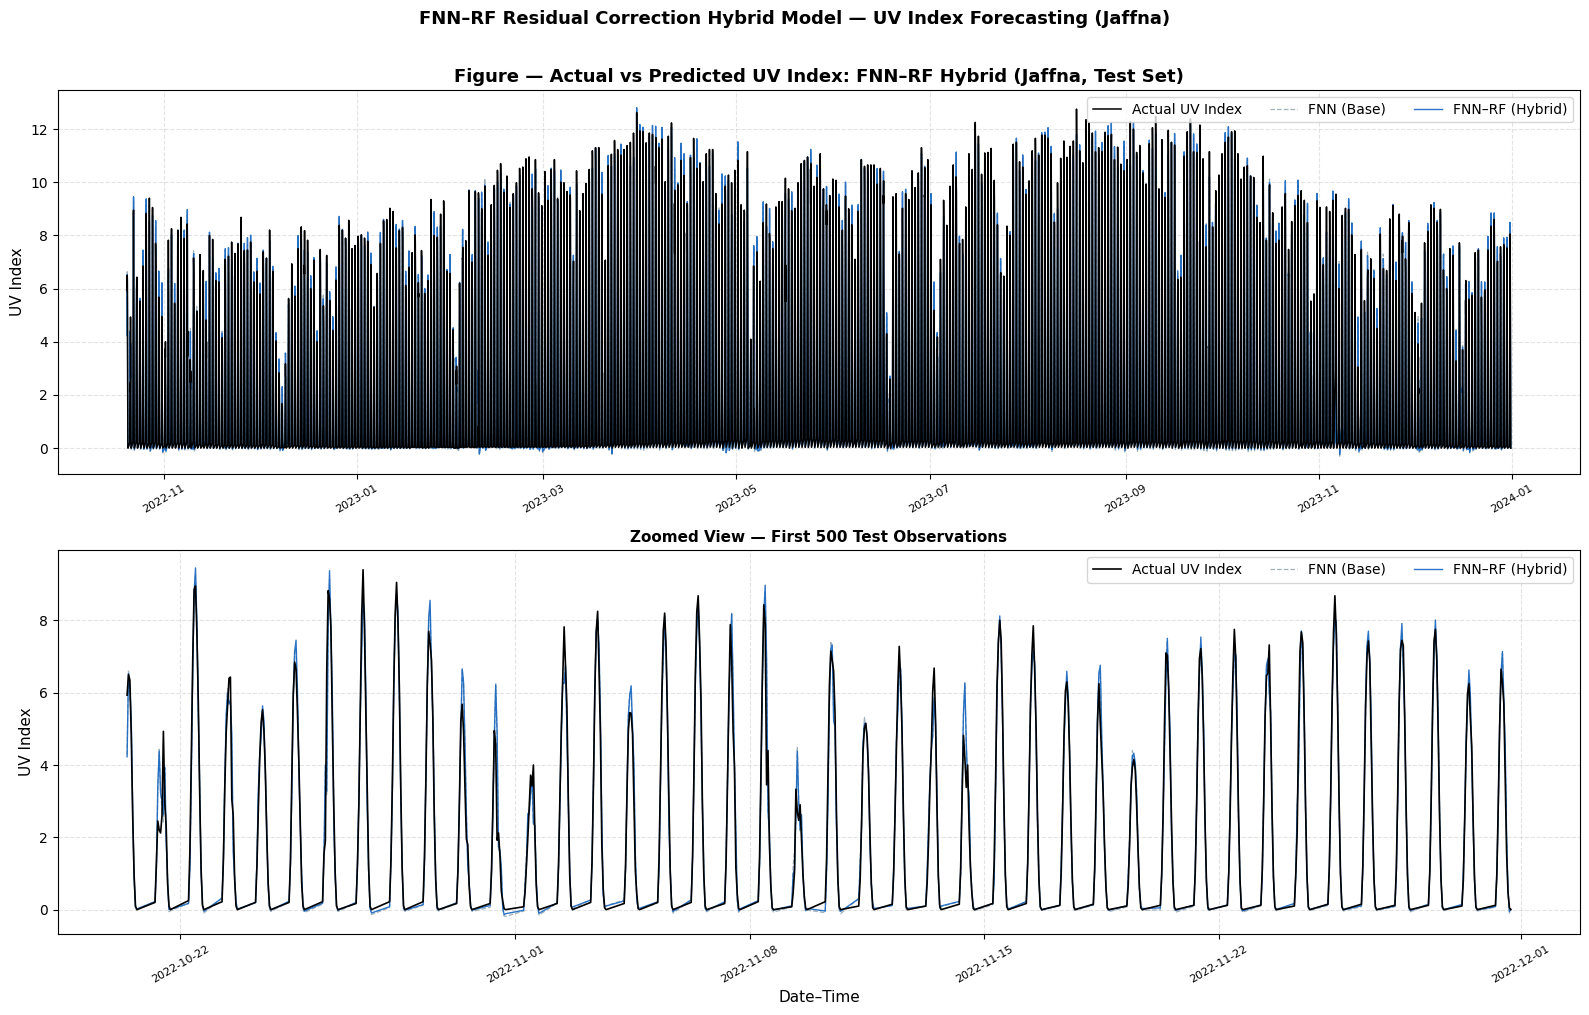

Saved → Fig_ActualVsPredicted_FNN_RF_Jaffna.png


In [10]:
# ── Reload predictions ────────────────────────────────────────────────────────
ck_fnn = load_ckpt_hybrid('FNN_base')
ck_rf  = load_ckpt_hybrid('FNN_RF_hybrid')

fnn_pred_test  = ck_fnn['pred_test']
hybrid_rf_pred = ck_rf['hybrid_pred_test']
y_actual       = y_test.values
time_index     = y_test.index

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# ── Top panel: full test period ───────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(time_index, y_actual,       color='black',  linewidth=1.1,
         label='Actual UV Index', zorder=5)
ax1.plot(time_index, fnn_pred_test,  color='#90A4AE', linewidth=0.9,
         linestyle='--', alpha=0.85, label='FNN (Base)')
ax1.plot(time_index, hybrid_rf_pred, color='#1565C0', linewidth=1.0,
         linestyle='-',  alpha=0.90, label='FNN–RF (Hybrid)')
ax1.set_title('Figure — Actual vs Predicted UV Index: FNN–RF Hybrid (Jaffna, Test Set)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('UV Index', fontsize=11)
ax1.legend(fontsize=10, loc='upper right', ncol=3)
ax1.grid(True, linestyle='--', alpha=0.35)
ax1.tick_params(axis='x', labelsize=8, rotation=30)

# ── Bottom panel: zoom into first 500 observations ───────────────────────────
n_zoom = min(500, len(time_index))
ax2 = axes[1]
ax2.plot(time_index[:n_zoom], y_actual[:n_zoom],
         color='black',  linewidth=1.2, label='Actual UV Index', zorder=5)
ax2.plot(time_index[:n_zoom], fnn_pred_test[:n_zoom],
         color='#90A4AE', linewidth=0.9, linestyle='--', alpha=0.85, label='FNN (Base)')
ax2.plot(time_index[:n_zoom], hybrid_rf_pred[:n_zoom],
         color='#1565C0', linewidth=1.0, linestyle='-',  alpha=0.90, label='FNN–RF (Hybrid)')
ax2.set_title(f'Zoomed View — First {n_zoom} Test Observations',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('UV Index', fontsize=11)
ax2.set_xlabel('Date–Time', fontsize=11)
ax2.legend(fontsize=10, loc='upper right', ncol=3)
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.tick_params(axis='x', labelsize=8, rotation=30)

plt.suptitle('FNN–RF Residual Correction Hybrid Model — UV Index Forecasting (Jaffna)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Fig_ActualVsPredicted_FNN_RF_Jaffna.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_ActualVsPredicted_FNN_RF_Jaffna.png')

---
## Cell 11 — Figure 2: Actual vs Predicted — FNN–XGB Hybrid

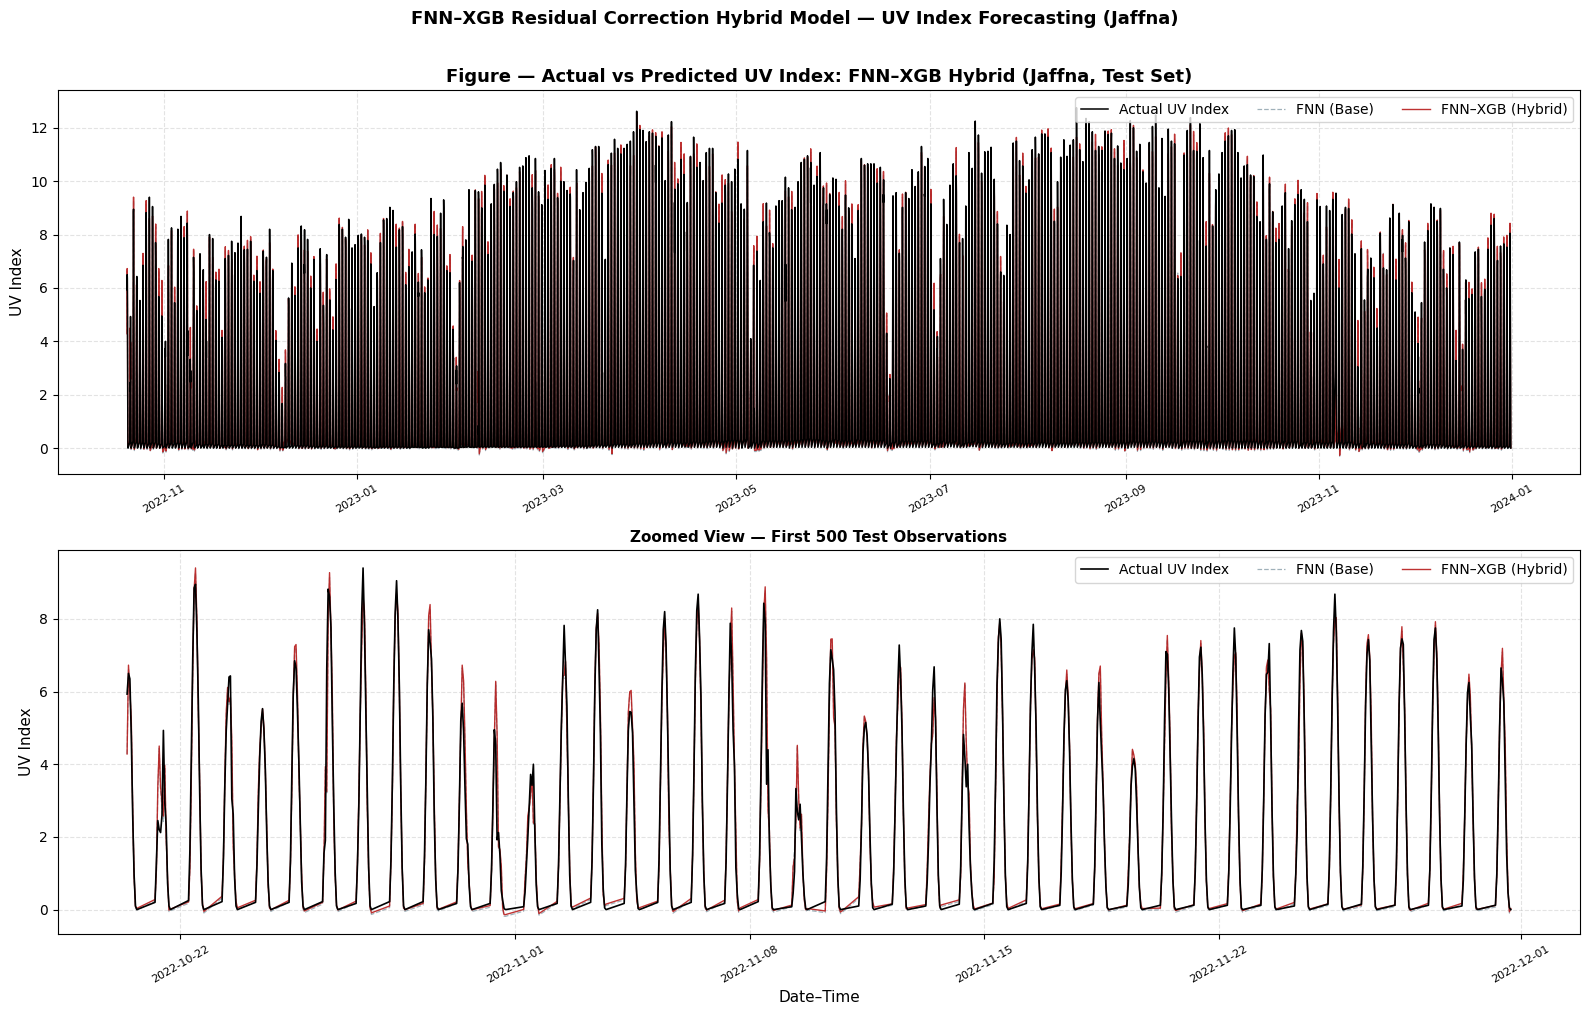

Saved → Fig_ActualVsPredicted_FNN_XGB_Jaffna.png


In [11]:
ck_xgb = load_ckpt_hybrid('FNN_XGB_hybrid')
hybrid_xgb_pred = ck_xgb['hybrid_pred_test']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# ── Top panel: full test period ───────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(time_index, y_actual,        color='black',  linewidth=1.1,
         label='Actual UV Index', zorder=5)
ax1.plot(time_index, fnn_pred_test,   color='#90A4AE', linewidth=0.9,
         linestyle='--', alpha=0.85, label='FNN (Base)')
ax1.plot(time_index, hybrid_xgb_pred, color='#B71C1C', linewidth=1.0,
         linestyle='-',  alpha=0.90, label='FNN–XGB (Hybrid)')
ax1.set_title('Figure — Actual vs Predicted UV Index: FNN–XGB Hybrid (Jaffna, Test Set)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('UV Index', fontsize=11)
ax1.legend(fontsize=10, loc='upper right', ncol=3)
ax1.grid(True, linestyle='--', alpha=0.35)
ax1.tick_params(axis='x', labelsize=8, rotation=30)

# ── Bottom panel: zoom into first 500 observations ───────────────────────────
n_zoom = min(500, len(time_index))
ax2 = axes[1]
ax2.plot(time_index[:n_zoom], y_actual[:n_zoom],
         color='black',  linewidth=1.2, label='Actual UV Index', zorder=5)
ax2.plot(time_index[:n_zoom], fnn_pred_test[:n_zoom],
         color='#90A4AE', linewidth=0.9, linestyle='--', alpha=0.85, label='FNN (Base)')
ax2.plot(time_index[:n_zoom], hybrid_xgb_pred[:n_zoom],
         color='#B71C1C', linewidth=1.0, linestyle='-',  alpha=0.90, label='FNN–XGB (Hybrid)')
ax2.set_title(f'Zoomed View — First {n_zoom} Test Observations',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('UV Index', fontsize=11)
ax2.set_xlabel('Date–Time', fontsize=11)
ax2.legend(fontsize=10, loc='upper right', ncol=3)
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.tick_params(axis='x', labelsize=8, rotation=30)

plt.suptitle('FNN–XGB Residual Correction Hybrid Model — UV Index Forecasting (Jaffna)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Fig_ActualVsPredicted_FNN_XGB_Jaffna.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_ActualVsPredicted_FNN_XGB_Jaffna.png')

---
## Cell 12 — Export Full Results CSV

In [12]:
ck_fnn = load_ckpt_hybrid('FNN_base')
ck_rf  = load_ckpt_hybrid('FNN_RF_hybrid')
ck_xgb = load_ckpt_hybrid('FNN_XGB_hybrid')

fnn_m = ck_fnn['metrics_test']
rf_m  = ck_rf['hybrid_metrics_test']
xgb_m = ck_xgb['hybrid_metrics_test']

export_rows = [
    {'Location': 'Jaffna', 'Window': WINDOW_NAME, 'N_Lags': N_LAGS,
     'Model': 'FNN',
     'MSE': round(fnn_m[0],6), 'RMSE': round(fnn_m[1],6),
     'MAE': round(fnn_m[2],6), 'MAPE': round(fnn_m[3],4), 'R2': round(fnn_m[4],6)},
    {'Location': 'Jaffna', 'Window': WINDOW_NAME, 'N_Lags': N_LAGS,
     'Model': 'FNN-RF',
     'MSE': round(rf_m[0],6),  'RMSE': round(rf_m[1],6),
     'MAE': round(rf_m[2],6),  'MAPE': round(rf_m[3],4),  'R2': round(rf_m[4],6)},
    {'Location': 'Jaffna', 'Window': WINDOW_NAME, 'N_Lags': N_LAGS,
     'Model': 'FNN-XGB',
     'MSE': round(xgb_m[0],6), 'RMSE': round(xgb_m[1],6),
     'MAE': round(xgb_m[2],6), 'MAPE': round(xgb_m[3],4), 'R2': round(xgb_m[4],6)},
]

results_df = pd.DataFrame(export_rows)
results_df.to_csv('Table_Hybrid_Results_Jaffna.csv', index=False)
print('Saved → Table_Hybrid_Results_Jaffna.csv\n')
print(results_df.to_string(index=False))

Saved → Table_Hybrid_Results_Jaffna.csv

Location                          Window  N_Lags   Model      MSE     RMSE      MAE         MAPE       R2
  Jaffna Long-term - Three Day (36 lags)      36     FNN 0.233408 0.483124 0.274048 2.136102e+07 0.980254
  Jaffna Long-term - Three Day (36 lags)      36  FNN-RF 0.220078 0.469125 0.251752 1.247083e+07 0.981382
  Jaffna Long-term - Three Day (36 lags)      36 FNN-XGB 0.226559 0.475983 0.261443 1.517894e+07 0.980833


---
## Cell 13 — Diebold-Mariano Test: FNN-RF vs FNN-XGB

The **Diebold-Mariano (DM) test** evaluates whether two forecasting models produce forecasts with **statistically significantly different accuracy**.  

- **H₀ (Null hypothesis):** The two hybrid models (FNN-RF and FNN-XGB) have equal predictive accuracy.  
- **H₁ (Alternative hypothesis):** The two hybrid models have significantly different predictive accuracy.  

A **p-value < 0.05** leads us to reject H₀ — indicating a significant difference in forecast accuracy between the two models.  
The loss differential is based on **squared errors** (MSE-based DM test).

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 13 — Diebold-Mariano Test: FNN-RF vs FNN-XGB Hybrid
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
from scipy import stats

# ── Load predictions from checkpoints ────────────────────────────────────────
ck_rf  = load_ckpt_hybrid('FNN_RF_hybrid')
ck_xgb = load_ckpt_hybrid('FNN_XGB_hybrid')

pred_rf  = np.array(ck_rf['hybrid_pred_test']).flatten()
pred_xgb = np.array(ck_xgb['hybrid_pred_test']).flatten()
actual   = np.array(y_actual).flatten()

# Align lengths (safety check)
n = min(len(actual), len(pred_rf), len(pred_xgb))
actual   = actual[:n]
pred_rf  = pred_rf[:n]
pred_xgb = pred_xgb[:n]

# ── Compute squared error loss differentials ──────────────────────────────────
e_rf  = (actual - pred_rf)  ** 2   # squared errors — FNN-RF
e_xgb = (actual - pred_xgb) ** 2   # squared errors — FNN-XGB
d     = e_rf - e_xgb               # loss differential (positive → RF is worse)

# ── Diebold-Mariano statistic ─────────────────────────────────────────────────
# DM statistic = mean(d) / sqrt(variance(d) / n)
# Using Newey-West HAC variance to account for autocorrelation in d
d_mean = np.mean(d)

# Newey-West HAC variance (bandwidth h = int(n^(1/3)) is standard for DM test)
h = int(n ** (1/3))   # forecast horizon proxy / lag truncation
gamma_0 = np.var(d, ddof=1)
hac_var = gamma_0
for lag in range(1, h + 1):
    gamma_lag = np.mean((d[lag:] - d_mean) * (d[:-lag] - d_mean))
    hac_var  += 2 * (1 - lag / (h + 1)) * gamma_lag   # Bartlett kernel

dm_stat = d_mean / np.sqrt(max(hac_var, 1e-12) / n)

# Two-sided p-value from standard normal
p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

alpha = 0.05

# ── Better model identification ───────────────────────────────────────────────
mae_rf  = np.mean(np.abs(actual - pred_rf))
mae_xgb = np.mean(np.abs(actual - pred_xgb))
better_model = 'FNN-RF' if mae_rf < mae_xgb else 'FNN-XGB'

# ── Print results ─────────────────────────────────────────────────────────────
print('=' * 62)
print('       DIEBOLD-MARIANO TEST: FNN-RF vs FNN-XGB')
print('=' * 62)
print(f'  Test observations (n)      : {n}')
print(f'  HAC lag truncation (h)     : {h}')
print(f'  Mean loss differential (d̄) : {d_mean:.6f}')
print(f'  DM statistic               : {dm_stat:.4f}')
print(f'  p-value (two-sided)        : {p_value:.4f}')
print(f'  Significance level (α)     : {alpha}')
print('-' * 62)
print(f'  MAE — FNN-RF               : {mae_rf:.6f}')
print(f'  MAE — FNN-XGB              : {mae_xgb:.6f}')
print(f'  Lower MAE (better model)   : {better_model}')
print('=' * 62)

# ── Decision ──────────────────────────────────────────────────────────────────
print('\n📋 DECISION:')
if p_value < alpha:
    print(f'  ✅ Reject H₀  (p = {p_value:.4f} < α = {alpha})')
    print(f'  There IS a statistically significant difference in predictive')
    print(f'  accuracy between FNN-RF and FNN-XGB at the {int(alpha*100)}% significance level.')
    print(f'  👉 {better_model} performs significantly better based on MAE.')
else:
    print(f'  ❌ Fail to reject H₀  (p = {p_value:.4f} ≥ α = {alpha})')
    print(f'  There is NO statistically significant difference in predictive')
    print(f'  accuracy between FNN-RF and FNN-XGB at the {int(alpha*100)}% significance level.')
    print(f'  👉 Both hybrid models are statistically equivalent in forecast accuracy.')
print('=' * 62)

       DIEBOLD-MARIANO TEST: FNN-RF vs FNN-XGB
  Test observations (n)      : 5252
  HAC lag truncation (h)     : 17
  Mean loss differential (d̄) : -0.006481
  DM statistic               : -4.5326
  p-value (two-sided)        : 0.0000
  Significance level (α)     : 0.05
--------------------------------------------------------------
  MAE — FNN-RF               : 0.251752
  MAE — FNN-XGB              : 0.261443
  Lower MAE (better model)   : FNN-RF

📋 DECISION:
  ✅ Reject H₀  (p = 0.0000 < α = 0.05)
  There IS a statistically significant difference in predictive
  accuracy between FNN-RF and FNN-XGB at the 5% significance level.
  👉 FNN-RF performs significantly better based on MAE.


---
## Utility — Clear Hybrid Checkpoints (run only if you want to retrain from scratch)

> ⚠️ Uncomment and run **only** if you need to fully retrain all hybrid models.

In [14]:
# import glob
# for f in glob.glob('checkpoint_hybrid/*.pkl'):
#     os.remove(f)
#     print(f'Deleted: {f}')
# print('All hybrid checkpoints cleared — re-run Cells 5–7 to retrain.')